In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

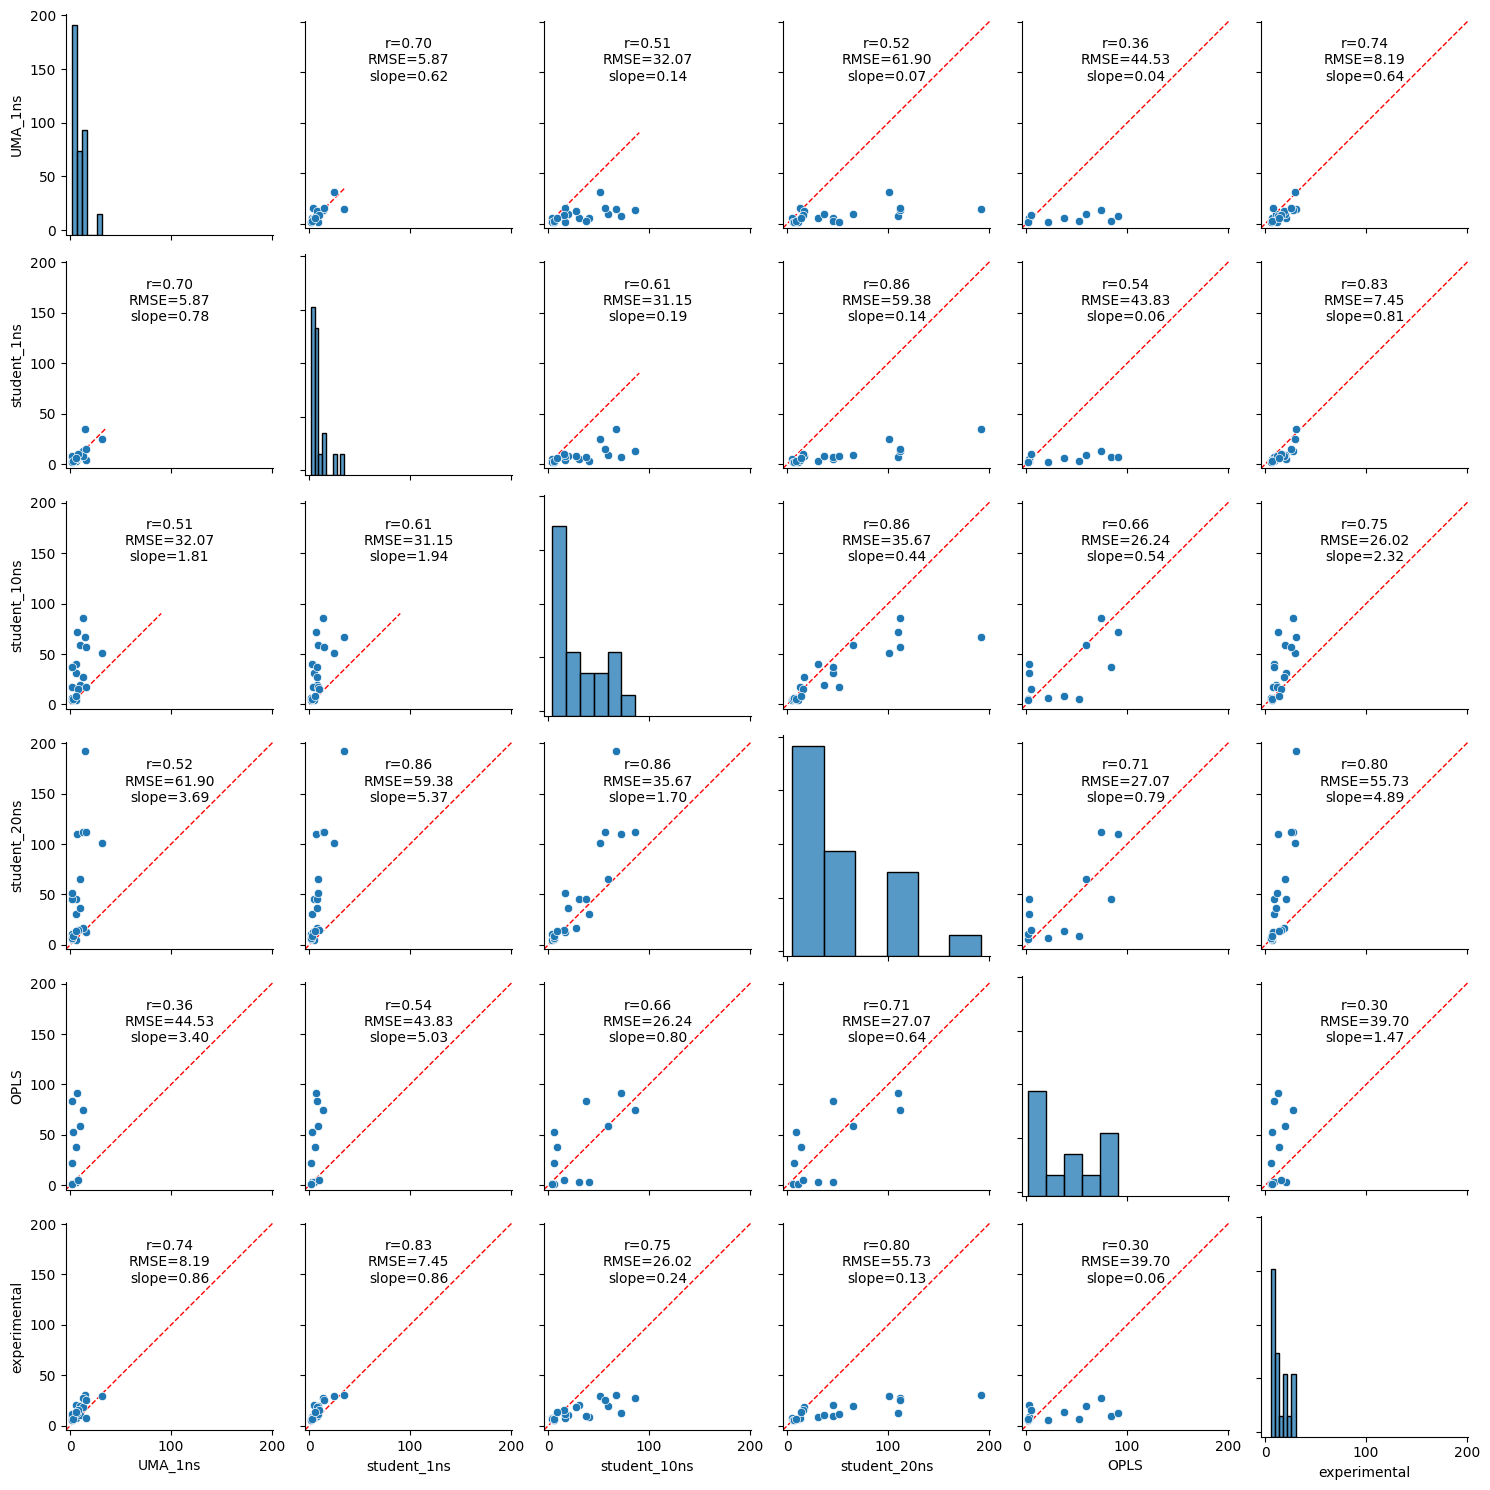

In [6]:
# path to your csv
csv_path = "/u/yjian1/project/MLFF-distill/plotting/results/uma_1ns_consistency.csv"

# CSV is transposed: rows = features, columns = samples — transpose so rows = samples
df = pd.read_csv(csv_path, index_col=0).T.reset_index(drop=True)
df.columns.name = None

# columns to compare
cols = [
    "UMA_1ns",
    "student_1ns",
    "student_10ns",
    "student_20ns",
    "OPLS",
    "experimental"
]

# convert to numeric (OPLS has missing entries that become NaN)
data = df[cols].apply(pd.to_numeric, errors='coerce')

from sklearn.metrics import mean_squared_error
from scipy.stats import linregress
import numpy as np

# pairplot
g = sns.pairplot(
    data,
    diag_kind="hist",
    corner=False
)

# annotate r, RMSE, slope; and draw red y=x diagonal on off-diagonal scatter plots
for i in range(len(cols)):
    for j in range(len(cols)):
        if i != j:
            ax = g.axes[i, j]
            if ax is not None:
                x = data[cols[j]]
                y = data[cols[i]]
                mask = x.notna() & y.notna()
                if mask.sum() >= 2:
                    r, _ = pearsonr(x[mask], y[mask])
                    # Compute RMSE manually to avoid 'squared' keyword issue
                    rmse = np.sqrt(mean_squared_error(x[mask], y[mask]))
                    slope, intercept, _, _, _ = linregress(x[mask], y[mask])
                    ax.text(
                        0.5, 0.92,
                        f"r={r:.2f}\nRMSE={rmse:.2f}\nslope={slope:.2f}",
                        transform=ax.transAxes,
                        ha="center", va="top"
                    )
                # y=x diagonal: enforce identical x/y limits, then draw corner-to-corner
                if mask.any():
                    xmin, xmax = ax.get_xlim()
                    ymin, ymax = ax.get_ylim()
                    lo = min(xmin, ymin)
                    hi = max(xmax, ymax)
                    ax.set_xlim(lo, hi)
                    ax.set_ylim(lo, hi)
                    ax.set_aspect("equal", adjustable="box")
                    ax.plot([lo, hi], [lo, hi], color="red", linewidth=1, linestyle="--", zorder=0)

plt.tight_layout()
plt.show()